El sistema astronómico de magnitudes y colores
===

Alumno
---
Pedro G. Villegas

Docentes
---
J.P. Calderón & R. Gamen

Resumen
---
Los filtros astronómicos permiten registrar parte del espectro
electromagnético de las estrellas en determinados rangos de
longitud de onda. Combinando las magnitudes en distintos filtros
se definen índices de color que nos ayudan a clasificar las
estrellas y estudiar sus características. El objetivo de esta
práctica es familiarizar al estudiante con los sistemas de
filtros más modernos y utilizarlos para cálculos sencillos.

Referencias
---
* [Práctica 02 (overleaf)](https://www.overleaf.com/read/qxwzwbnpbdnr)

---
      
Ejercicios
---
Objetivos:
* Calcular la longitud de onda efectiva y equivalente, teniendo en cuenta la sensibilidad de un determinado filtro y el flujo emitido por una determinada fuente.
* Graficar la sensibilidad de un sistema de filtros.
* Calcular los colores instrumentales a partir de una fuente de energía.
* Convolucionar un espectro estelar con la sensibilidad de un filtro y obtener la magnitud integrada.

**1.** Graficar las sensibilidades de los filtros. Tanto desde un archivo descargado, como desde un dado _url_.

In [ ]:
import pandas as pd
data = pd.read_csv ( 'UBVRI.dat', names = [ 'filtro','long','sen','sen_nor' ], 
                    sep = " ", comment = '#', header = None )
data # Se accede a cada columna mediante: data[0], data[1], ...
#plt.rc('text', usetex=False) #Desactivo el renderizado con LaTeX para evitar conflictos de compilación en los ejes

,filtro,long,sen,sen_nor
0,B,3600,0.00,0.00
1,B,3650,0.00,0.00
2,B,3700,0.02,0.02
3,B,3750,0.05,0.05
4,B,3800,0.11,0.11
...,...,...,...,...
304,V,7150,0.01,0.01
305,V,7200,0.01,0.01
306,V,7250,0.01,0.01
307,V,7300,0.01,0.01


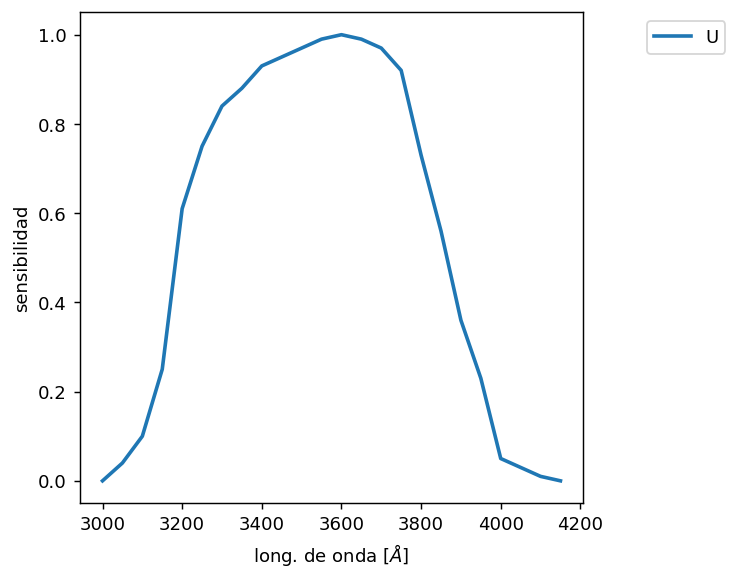

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (5, 5), dpi = 130 )

ax.plot ( 
    data[ (data['filtro']=='U') ]['long'], 
    data[ (data['filtro']=='U') ]['sen'], 
    linewidth = 2, label = "U" 
)

ax.set_xlabel ( 'long. de onda [$\AA$]' ) 
ax.set_ylabel ( 'sensibilidad' )

plt.legend ( bbox_to_anchor = (1.3,1), ncol = 1 )
plt.show()

¿Cómo filtrar el archivo de entrada en bandas (U, B, V)?

In [3]:
dataU = data[ data['filtro'] == 'U' ] 
#dataU

In [4]:
dataU = data[ data['filtro'] == 'U' ] 
dataB = data[ data['filtro'] == 'B' ]
dataV = data[ data['filtro'] == 'V' ] 
dataR = data[ data['filtro'] == 'R' ]
dataI = data[ data['filtro'] == 'I' ]
dataU #Muestra la tabla de valores que le estoy pidiendo

,filtro,long,sen,sen_nor
229,U,3000,0.00,0.00
230,U,3050,0.04,0.04
231,U,3100,0.10,0.10
232,U,3150,0.25,0.25
233,U,3200,0.61,0.61
234,U,3250,0.75,0.75
235,U,3300,0.84,0.84
236,U,3350,0.88,0.88
237,U,3400,0.93,0.93
238,U,3450,0.95,0.95


In [5]:
# completar data[ (data['long'] < 7000) & (data^['filtro'] == 'B')] []

In [6]:
#gmos_g[1].max() me devuelve de la tabla en pandas?? el máximo de la primer columna de datos

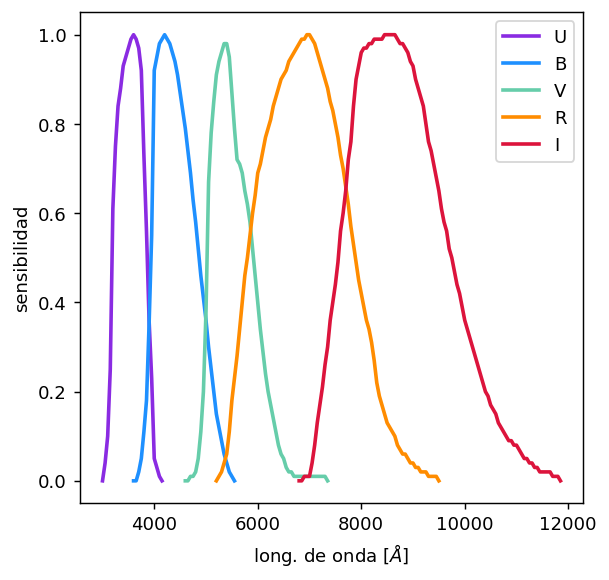

In [7]:
fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (5, 5), dpi = 130 )

ax.plot ( dataU['long'], dataU['sen'], linewidth = 2, color = 'blueviolet', label = "U" )
ax.plot ( dataB['long'], dataB['sen'], linewidth = 2, color = 'dodgerblue', label = "B" )
ax.plot ( dataV['long'], dataV['sen'], linewidth = 2, color = 'mediumaquamarine', label = "V" )
ax.plot ( dataR['long'], dataR['sen'], linewidth = 2, color = 'darkorange', label = "R" )
ax.plot ( dataI['long'], dataI['sen'], linewidth = 2, color = 'crimson', label = "I" )

#Cómo hago si quisiera rellenar el área bajo estas curvas?

ax.set_xlabel ( 'long. de onda [$\AA$]' )
ax.set_ylabel ( 'sensibilidad' )

plt.legend ( bbox_to_anchor = (1,1), ncol = 1 )
plt.show()

Descargo el archivo de sensibilidades de la página de GEMINI:

In [8]:
gmos_Ha = pd.read_csv ( 'http://www.gemini.edu/sciops/instruments/gmos/filters/gmos_s_Ha_G0336_jun2017.txt', 
                     sep = "  ", comment = '#', header = None ) # le puse dos espacios de separacion
gmos_HaC = pd.read_csv ( 'http://www.gemini.edu/sciops/instruments/gmos/filters/gmos_s_HaC_G0337_jun2017.txt', 
                     sep = "  ", comment = '#', header = None )

<ipython-input-8-e49665c0b0b6>:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  gmos_Ha = pd.read_csv ( 'http://www.gemini.edu/sciops/instruments/gmos/filters/gmos_s_Ha_G0336_jun2017.txt',
<ipython-input-8-e49665c0b0b6>:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  gmos_HaC = pd.read_csv ( 'http://www.gemini.edu/sciops/instruments/gmos/filters/gmos_s_HaC_G0337_jun2017.txt',


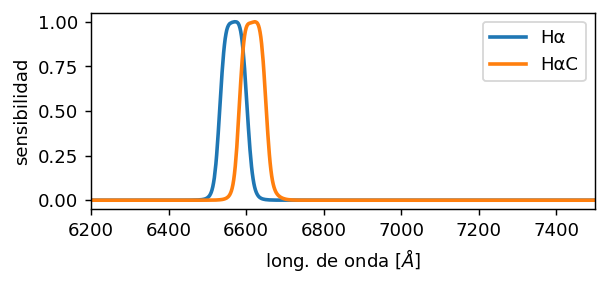

In [9]:
fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (5, 2), dpi = 130 )

ax.plot ( gmos_Ha[0] * 10., gmos_Ha[1]/ gmos_Ha[1].max(), linewidth = 2, label = 'Hα' ) # Paso la long. de onda de nm a \AA
ax.plot ( gmos_HaC[0] * 10., gmos_HaC[1]/ gmos_HaC[1].max(), linewidth = 2, label = 'HαC' )

ax.set_xlim ( 6200, 7500)
ax.set_xlabel ( 'long. de onda [$\AA$]' )
ax.set_ylabel ( 'sensibilidad' )

plt.legend ( bbox_to_anchor = (1,1), ncol = 1 )
plt.show()

In [10]:
gmos_u = pd.read_csv ( 'http://www.gemini.edu/sciops/instruments/gmos/filters/gmos_s_u_G0332_jun2017.txt', 
                     sep = "  ", comment = '#', header = None )
gmos_g = pd.read_csv ( 'http://www.gemini.edu/sciops/instruments/gmos/filters/gmos_s_g_G0325_jun2017.txt', 
                     sep = "  ", comment = '#', header = None )
gmos_r = pd.read_csv ( 'http://www.gemini.edu/sciops/instruments/gmos/filters/gmos_s_r_G0326_jun2017.txt', 
                     sep = "  ", comment = '#', header = None )
gmos_i = pd.read_csv ( 'http://www.gemini.edu/sciops/instruments/gmos/filters/gmos_s_i_G0327_jun2017.txt', 
                     sep = "  ", comment = '#', header = None )

<ipython-input-10-25890b1ec0b6>:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  gmos_u = pd.read_csv ( 'http://www.gemini.edu/sciops/instruments/gmos/filters/gmos_s_u_G0332_jun2017.txt',
<ipython-input-10-25890b1ec0b6>:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  gmos_g = pd.read_csv ( 'http://www.gemini.edu/sciops/instruments/gmos/filters/gmos_s_g_G0325_jun2017.txt',
<ipython-input-10-25890b1ec0b6>:5: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this

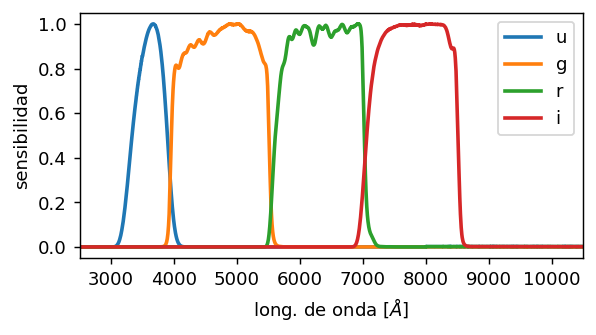

In [11]:
fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (5, 2.5), dpi = 130 )

ax.plot ( gmos_u[0] * 10., gmos_u[1]/ gmos_u[1].max(), linewidth = 2, label = 'u' )
ax.plot ( gmos_g[0] * 10., gmos_g[1]/ gmos_g[1].max(), linewidth = 2, label = 'g' )
ax.plot ( gmos_r[0] * 10., gmos_r[1]/ gmos_r[1].max(), linewidth = 2, label = 'r' )
ax.plot ( gmos_i[0] * 10., gmos_i[1]/ gmos_i[1].max(), linewidth = 2, label = 'i' )

ax.set_xlim ( 2500, 10500)
ax.set_xlabel ( 'long. de onda [$\AA$]' )
ax.set_ylabel ( 'sensibilidad' )

plt.legend ( bbox_to_anchor = (1,1), ncol = 1 )
plt.show()

**2.** Calcular la longitud de onda equivalente y efectiva

Sin considerar la radiación proveniente de la fuente, se puede definir
la longitud de onda media o equivalente $\lambda_{0}$ de un filtro,
de la siguiente forma:

\begin{equation}
  \lambda_{0} = \frac{\int \lambda ~ S(\lambda) ~ d\lambda }{\int S(\lambda) ~ d\lambda}
\end{equation}

en donde $S(\lambda)$ representa la función de transmición del
filtro. Si, por lo contrario, se tiene en cuenta la distribución de
energía de la fuente, se puede definir la longitud de onda efectiva
$\lambda_{e}$:

\begin{equation}
  \lambda_{e} = \frac{\int \lambda ~ S(\lambda) ~ F(\lambda) ~ d\lambda }{\int S(\lambda) ~ F(\lambda) ~ d\lambda} 
\end{equation}

en donde $F(\lambda)$ es la distribución de energía de la fuente.

Para hacer lo anterior, utilizaremos el método de integración para datos provenientes de un archivo de texto:

En este caso vamos a mostrar cómo integrar mediante el [método de Simpson](https://es.wikipedia.org/wiki/Regla_de_Simpson) (```simp``` de ```scipy```) y vamos a usar el módelo de cuerpo negro (```BlackBody``` de ```astropy```).
El método de Simpson utiliza subintervalos de la dada función $f(x)$ aproximando por un polinomio de primer grado $P(x)$:

\begin{equation}
\int_a^b f(x)\ dx \equiv \frac{\Delta x}{3} \sum_{i = 1}^{N/2} \left[f(x_{2i-2}) + 4 f(x_{2i-1}) + f(x_{2i}) \right]
\end{equation}

dónde $\Delta x = (b-a)/N$, $x_{i} = a + i \Delta x$.

Manual de ```simp```: https://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.integrate.simps.html

In [12]:
from astropy.modeling.models import BlackBody
from astropy import units as u

bb = BlackBody ( temperature = 6000 * u.K )
print(bb(4000 * u.AA))

1.5504456087808982e-05 erg / (cm2 Hz s sr)


In [13]:
from scipy.integrate import simps
import numpy as np

LOM_numerador = simps( dataB['long'] * dataB['sen'], x = dataB['long'] ) # Borrar el argumento
LOM_denominador = simps( dataB['sen'], x = dataB['long'] )

print ( "[*] Long. de onda media [$\AA$] = ", LOM_numerador/LOM_denominador )

# Para la integral por Simpson, _python_u tiene:
# integral = simps( integrando['X'], x = X ) 

[*] Long. de onda media [$\AA$] =  4439.335994035349


In [14]:
# Faltaría calcular la long de onda efectiva. He aqui:

LOE_numerador = simps( dataV['long'] * dataV['sen'] * bb(dataV['long']), x = dataV['long'])
LOE_denominador = simps( dataV['sen'] * bb(dataV['long']), x = dataV['long'])

print ("Longitud de onda efectiva [$\AA$] = ", LOE_numerador/LOE_denominador)

Longitud de onda efectiva [$\AA$] =  5588.277416787293


**3.** Vamos a unir los archivos de la distribución de energia $F(\lambda)$ y la sensibilidad $S(\lambda)$ del filtro para calcular el índice de color


\begin{equation}
  m_{V} = C_{0V} - 2.5\ log\left(\int F(\lambda)\ S(\lambda)\ d\lambda\right)
\end{equation}

dónde $C_{0V}$ es el punto de cero del filtro. Luego, calculando lo mismo para el filtro B, se puede obtener el índice de color 

\begin{equation}
  (b-v) = m_{B} - m_{v}
\end{equation}

In [15]:
# Primer parte
# Defino una matriz con los puntos de cero de cada filtro
C = pd.DataFrame ( {"C0": [21.100, 21.750, 20.830]}, index = ['V', 'B', 'U'] )  
print (C)

      C0
V  21.10
B  21.75
U  20.83


In [16]:
print ( C.loc['V','C0'] )

21.1


In [17]:
# Segunda parte -> Habla sólo de la radiación incidente al filtro (estrella K5V)
distribucion = pd.read_csv("distribucion_espectral_K5V.dat", names = ['long2', 'int'],
                           sep = " ", comment = '#', header = None)
distribucion['long2'] = distribucion['long2'] * 10. # Para convertir la long. de onda de nm a AA.
print ( distribucion )

       long2   int
0     1200.0   0.0
1     1250.0   0.0
2     1300.0   0.0
3     1350.0   0.0
4     1400.0   0.0
..       ...   ...
183  10350.0  80.5
184  10400.0  81.2
185  10450.0  80.0
186  10500.0  78.5
187  12500.0  54.0

[188 rows x 2 columns]


In [18]:
# Tercer parte

#  Filtro la distribución de la fuente según la long. de onda
#   disponible en el archivo de sensibilidades.

min = dataV['long'].min() # Calculo el minimo y máximo
max = dataV['long'].max() #  de las long. de onda.
#print ( "[*] min y máx de la long. de onda (V) = ", min, max )

In [19]:
dist_filtrada = distribucion[ (distribucion['long2'] >= min) & (distribucion['long2'] <= max) ] # Filtro por banda.
##      Notar: el espaciado en de la sensibilidad y de la distribucion es la misma (50 AA),
##             por lo que no hay que hacer ninguna interpolación.
#print ( dist_filtrada )

In [20]:
# Noten que ambas matrices tienen el mismo tamaño
#print ( len(dist_filtrada), len(dataV) )

In [21]:
# Cuarta parte
dataV = dataV.reset_index ( drop = True ) # Vuelve a cero los indices.
dist_filtrada = dist_filtrada.reset_index ( drop = True )

# como tienen el mismo tamaño, lo puedo pegar:
output = dist_filtrada.join(dataV)
print(output)

     long2    int filtro  long   sen  sen_nor
0   4600.0   81.0      V  4600  0.00    0.000
1   4650.0   82.0      V  4650  0.00    0.000
2   4700.0   82.2      V  4700  0.01    0.010
3   4750.0   79.0      V  4750  0.01    0.010
4   4800.0   76.0      V  4800  0.02    0.020
5   4850.0   79.5      V  4850  0.05    0.051
6   4900.0   79.5      V  4900  0.11    0.112
7   4950.0   78.0      V  4950  0.20    0.204
8   5000.0   72.0      V  5000  0.38    0.388
9   5050.0   66.5      V  5050  0.67    0.684
10  5100.0   62.0      V  5100  0.78    0.796
11  5150.0   60.5      V  5150  0.85    0.867
12  5200.0   61.8      V  5200  0.91    0.929
13  5250.0   77.0      V  5250  0.94    0.959
14  5300.0   88.0      V  5300  0.96    0.980
15  5350.0   92.0      V  5350  0.98    1.000
16  5400.0   93.5      V  5400  0.98    1.000
17  5450.0   96.5      V  5450  0.95    0.969
18  5500.0  100.0      V  5500  0.87    0.888
19  5550.0  104.0      V  5550  0.79    0.806
20  5600.0  101.5      V  5600  0.

In [22]:
# Quinta parte
V = C.loc['V','C0'] - 2.5 * np.log10 ( simps(output['int']*output['sen'], x = output['long']) )
print ("[*]  V = ", V)

[*]  V =  8.804929075332474


In [23]:
# Falta calculo en los filtros U, y B

In [24]:
# Hago todo el cálculo para el filtro U:

min = dataU['long'].min() # Calculo el minimo y máximo
max = dataU['long'].max() #  de las long. de onda disponibles en dataU


# 'Distribución' es el archivo de datos de la estrella. 
# Acá me estoy quedando con la información proveniente de la estrella que está
# entre las long. de onda presentes en el archivo de datos del filtro.
dist_filtrada = distribucion[ (distribucion['long2']>=min) & (distribucion['long2']<=max) ]

dataU = dataU.reset_index ( drop = True ) # Vuelve a cero los indices.
dist_filtrada = dist_filtrada.reset_index ( drop = True )

# como tienen el mismo tamaño, lo puedo pegar:
output_U = dist_filtrada.join(dataU)
print(output_U)

# Por último, calculo la magnitud en U:
U = C.loc['U','C0'] - 2.5 * np.log10 ( simps(output_U['int']*output_U['sen'], x = output_U['long']) )
print ("[*]  U = ", U)

     long2   int filtro  long   sen  sen_nor
0   3000.0   1.5      U  3000  0.00     0.00
1   3050.0   2.2      U  3050  0.04     0.04
2   3100.0   3.5      U  3100  0.10     0.10
3   3150.0   4.9      U  3150  0.25     0.25
4   3200.0   7.0      U  3200  0.61     0.61
5   3250.0   6.2      U  3250  0.75     0.75
6   3300.0   9.8      U  3300  0.84     0.84
7   3350.0  10.5      U  3350  0.88     0.88
8   3400.0  11.8      U  3400  0.93     0.93
9   3450.0  11.0      U  3450  0.95     0.95
10  3500.0  12.8      U  3500  0.97     0.97
11  3550.0  12.8      U  3550  0.99     0.99
12  3600.0  11.0      U  3600  1.00     1.00
13  3650.0  15.4      U  3650  0.99     0.99
14  3700.0  15.4      U  3700  0.97     0.97
15  3750.0  11.5      U  3750  0.92     0.92
16  3800.0  15.2      U  3800  0.73     0.73
17  3850.0  11.0      U  3850  0.56     0.56
18  3900.0  14.8      U  3900  0.36     0.36
19  3950.0  15.8      U  3950  0.23     0.23
20  4000.0  29.4      U  4000  0.05     0.05
21  4050.0

In [25]:
# Hago todo el cálculo para el filtro B:

min = dataB['long'].min() # Calculo el minimo y máximo
max = dataB['long'].max() #  de las long. de onda disponibles en dataU


# 'Distribución' es el archivo de datos de la estrella. 
# Acá me estoy quedando con la información proveniente de la estrella que está
# entre las long. de onda presentes en el archivo de datos del filtro.
dist_filtrada = distribucion[ (distribucion['long2']>=min) & (distribucion['long2']<=max) ]

dataB = dataB.reset_index ( drop = True ) # Vuelve a cero los indices.
dist_filtrada = dist_filtrada.reset_index ( drop = True )

# como tienen el mismo tamaño, lo puedo pegar:
output_B = dist_filtrada.join(dataB)
print(output_B)

# Por último, calculo la magnitud en U:
B = C.loc['B','C0'] - 2.5 * np.log10 ( simps(output_B['int']*output_B['sen'], x = output_B['long']) )
print ("[*]  B = ", B)

     long2    int filtro  long   sen  sen_nor
0   3600.0   11.0      B  3600  0.00     0.00
1   3650.0   15.4      B  3650  0.00     0.00
2   3700.0   15.4      B  3700  0.02     0.02
3   3750.0   11.5      B  3750  0.05     0.05
4   3800.0   15.2      B  3800  0.11     0.11
5   3850.0   11.0      B  3850  0.18     0.18
6   3900.0   14.8      B  3900  0.35     0.35
7   3950.0   15.8      B  3950  0.55     0.55
8   4000.0   29.4      B  4000  0.92     0.92
9   4050.0   30.4      B  4050  0.95     0.95
10  4100.0   38.5      B  4100  0.98     0.98
11  4150.0   39.0      B  4150  0.99     0.99
12  4200.0   36.8      B  4200  1.00     1.00
13  4250.0   33.6      B  4250  0.99     0.99
14  4300.0   40.0      B  4300  0.98     0.98
15  4350.0   55.6      B  4350  0.96     0.96
16  4400.0   53.0      B  4400  0.94     0.94
17  4450.0   62.0      B  4450  0.91     0.91
18  4500.0   72.5      B  4500  0.87     0.87
19  4550.0   74.5      B  4550  0.83     0.83
20  4600.0   81.0      B  4600  0.

In [26]:
print ("[*] color instrumental (b-v) = ", B-V) #1.1532222025718628

[*] color instrumental (b-v) =  1.1532222025718628


In [27]:
print ("[*] color instrumental (u-b) = ", U-B) #1.1461077110271987

[*] color instrumental (u-b) =  1.1461077110271987


**3.** Diagrama color-color

In [42]:
# Constantes del diagrama color - color del cuerpo negro

from astropy.modeling.models import BlackBody
from astropy import units as u

h = 6.62607015e-34 # Jseg
c = 29979245800.0  # mseg^-1
k = 1.380649e-23   # JK^-1

C2 = h*c/k  # m K

# ·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·

# Cuerpo negro a 6000K
bb = BlackBody ( temperature = 6000 * u.K )

# Longitudes de onda efectivas para el cuerpo negro en los filtros UBV
LOE_numerador = simps( dataU['long'] * dataU['sen'] * bb(dataU['long']), x = dataU['long'])
LOE_denominador = simps( dataU['sen'] * bb(dataU['long']), x = dataU['long'])
lambdaeffu = LOE_numerador/LOE_denominador

LOE_numerador = simps( dataB['long'] * dataB['sen'] * bb(dataB['long']), x = dataB['long'])
LOE_denominador = simps( dataB['sen'] * bb(dataB['long']), x = dataB['long'])
lambdaeffb = LOE_numerador/LOE_denominador

LOE_numerador = simps( dataV['long'] * dataV['sen'] * bb(dataV['long']), x = dataV['long'])
LOE_denominador = simps( dataV['sen'] * bb(dataV['long']), x = dataV['long'])
lambdaeffv = LOE_numerador/LOE_denominador

#print ('Lambda u=',lambdaeffu ,'Lambda b=',lambdaeffb ,'Lambda v=',lambdaeffv )
# ·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·

# Vuelvo a definir los puntos cero de los filtros pues sino tira problemas
Cero = pd.DataFrame ({"C0": [21.100, 21.750, 20.830]}, index = ['V', 'B', 'U'])

Cu = Cero.loc['U','C0'] - 2.5*np.log10( simps(dataU['sen'], x = dataU['long'] ))
Cb = Cero.loc['B','C0'] - 2.5*np.log10( simps(dataB['sen'], x = dataB['long'] ))
Cv = Cero.loc['V','C0'] - 2.5*np.log10( simps(dataV['sen'], x = dataV['long'] ))

print (Cu, Cb, Cv)
# ·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·

A  = Cb - Cv - 5 * 2.5 * np.log10(lambdaeffv/lambdaeffb)
Aa = 2.5 * C2 * np.log10(np.e) * (1/lambdaeffb - 1/lambdaeffv)
C  = Cu - Cb - 5 * 2.5 * np.log10(lambdaeffb/lambdaeffu)
Cc = 2.5 * C2 * np.log10(np.e) * (1/lambdaeffu - 1/lambdaeffb)

print ('A = ', A,)
print ('Aa = ', Aa)
print ('C = ', C)
print ('Cc = ', Cc)

13.78409155891081 14.305643367813168 13.733204261670254
A =  -0.6088404562768781
Aa =  6.795256319559915e-05
C =  -1.7854520236293048
Cc =  9.109553129017977e-05


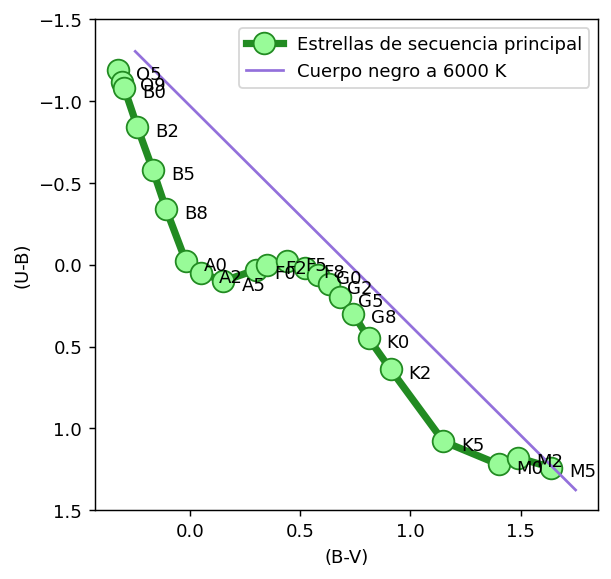

In [47]:
import matplotlib.pyplot as plt

wav = np.arange(-0.25,2)
diagrama = pd.read_csv ( 'V.dat', sep = " ", comment = '#' )

fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (5, 5), dpi = 130 )
ax.plot( 'B-V', 'U-B', data = diagrama, marker = 'o', 
         markerfacecolor = 'palegreen', markersize = 12, color = 'forestgreen', linewidth = 4, label = 'Estrellas de secuencia principal' )
ax.plot(wav,C - Cc*A/Aa + (Cc/Aa) * wav, color = 'mediumpurple', label = 'Cuerpo negro a 6000 K')

# Agrega el tipo espectral
for i in diagrama.index:
    plt.annotate ( diagrama.loc[i]['Sp'], xy = ( diagrama.loc[i]['B-V'], diagrama.loc[i]['U-B'] ),
                xytext = (10, -5), textcoords = 'offset points',
                family = 'sans-serif', fontsize = 10, color = 'black' )
        
ax.set_ylim(-1.5,1.5)
ax.set_xlabel('(B-V)')
ax.set_ylabel('(U-B)')
plt.gca().invert_yaxis()
plt.legend ( bbox_to_anchor = (1,1), ncol = 1 )
plt.show()

**4.** Descargo la distribución espectral de una estrella tipo A0 de Vizier (en formato pandas) y convoluciono con la sensibilidad del filtro V (que ya teniamos cargado).

In [30]:
A7V = pd.read_csv("http://cdsarc.u-strasbg.fr/viz-bin/nph-Plot/Vgraph/txt?VI%2f50&I%28A7V%29", 
                 names = ['l','I'], sep = "\t", comment = '#', header = None)
A7V['l'] = A7V['l'] * 10. # Para convertir la long. de onda de nm a AA.

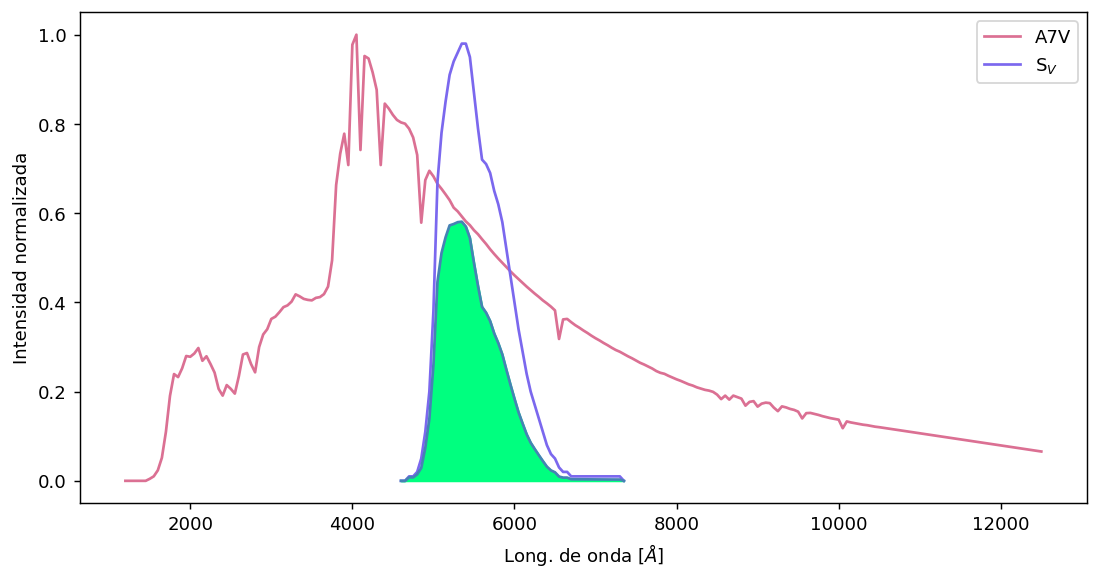

In [31]:
fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (10, 5), dpi = 130 )
ax.plot ( A7V['l'], A7V['I']/A7V['I'].max(), color = "palevioletred" ) # Normalizo con el máximo de la distribución
ax.plot ( dataV['long'], dataV['sen'], color = "mediumslateblue" )

## Filtro la distribución, teniendo en cuenta el máx y mín del archivo de sensibilidades
A7V_filtrada =  A7V[(A7V['l'] >= dataV['long'].min()) & (A7V['l'] <= dataV['long'].max())] # Filtro por banda

dataV = dataV.reset_index(drop=True) # Vuelve a cero los indices.
A7V_filtrada = A7V_filtrada.reset_index(drop=True)

output = A7V_filtrada.join(dataV) # Junto las matrices
#print (output)
##

ax.plot ( output['long'], output['I']*output['sen']/A7V['I'].max(), color = "steelblue" )

ax.fill_between( output['long'], 0, output['I']*output['sen']/A7V['I'].max(), 
                 color = "springgreen", interpolate = True )

plt.legend(labels = ['A7V','S$_{V}$'])

plt.xlabel('Long. de onda [$\AA$]')
plt.ylabel('Intensidad normalizada')

plt.show()